# Vergleich: Personenanzahl


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr


In [2]:
DATA_DIR = Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '12_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_structural_personen_anzahl.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(df[['influencer_type', 'personen_anzahl', 'personen_anzahl_max', 'detected_person_frames']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ..\..\data\04_analysis_results\visual_features\12_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_structural_personen_anzahl.csv
                personen_anzahl                     personen_anzahl_max  \
                          count      mean       std               count   
influencer_type                                                           
ai                          250  2.332465  1.594694                 250   
real                        250  1.931053  0.869037                 250   

                                 detected_person_frames                    
                  mean       std                  count    mean       std  
influencer_type                                                            
ai               4.440  2.601822                    250  13.476  6.026833  
real             4.668  4.815239                    250  17.144  6.693765  


In [3]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


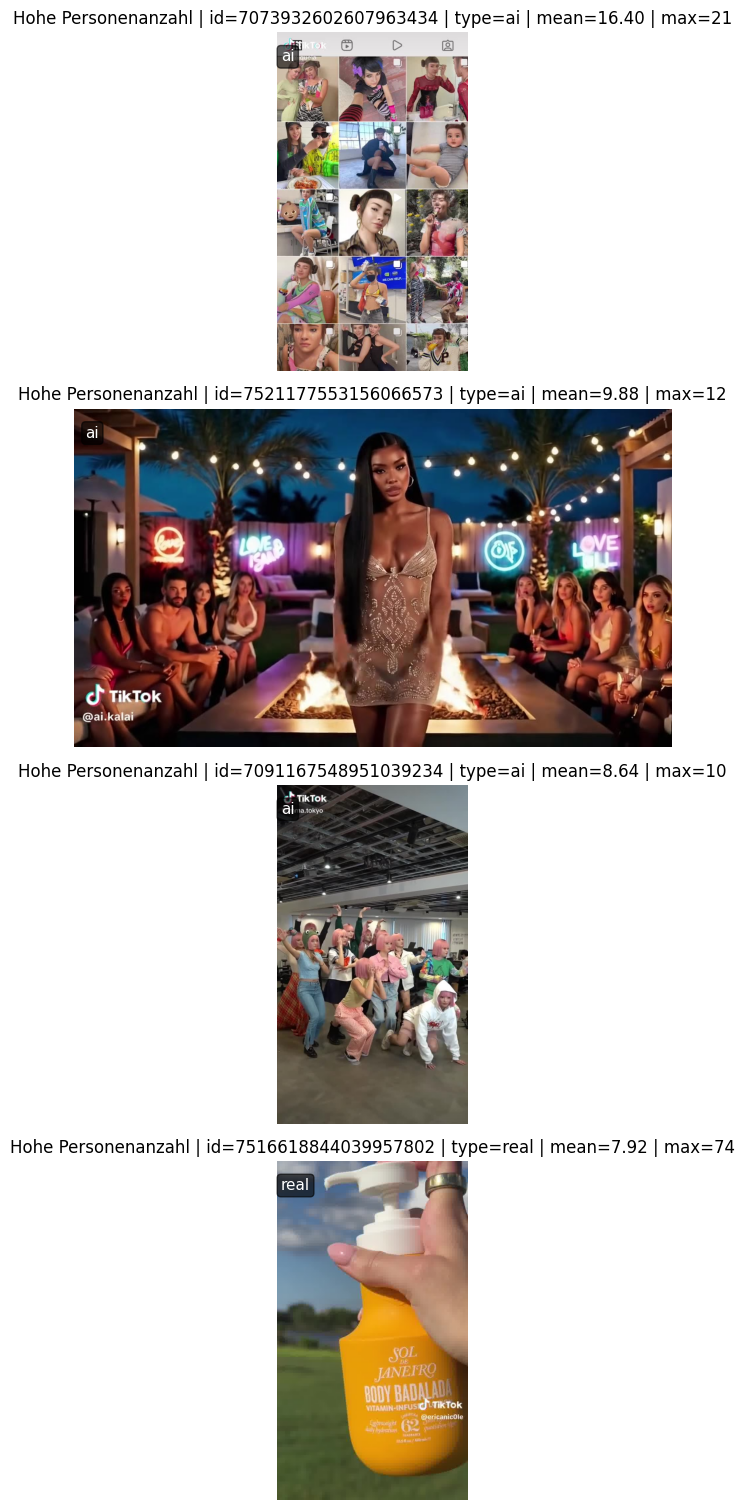

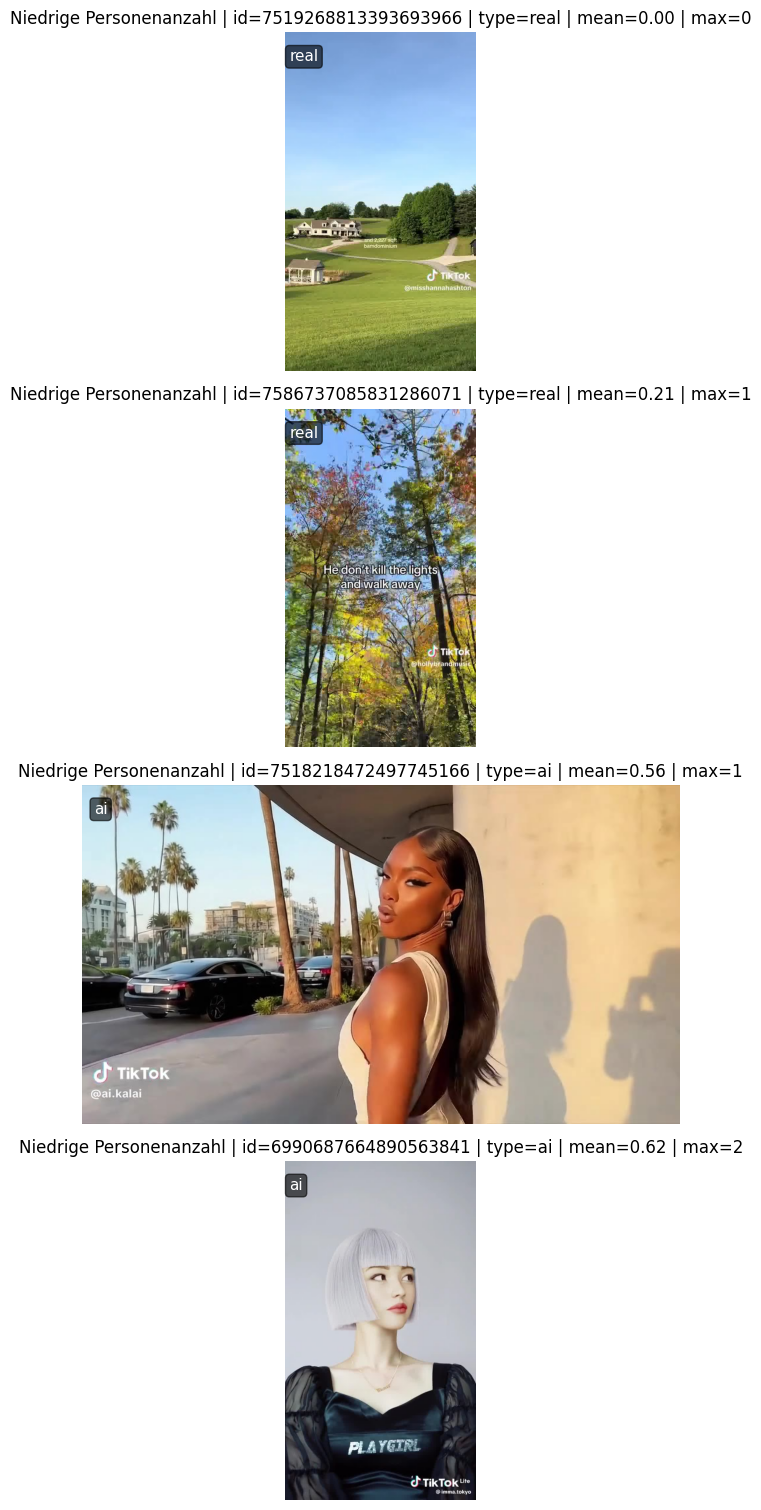

In [4]:
# Beispiele mit hoher und niedriger Personenanzahl anzeigen
_df = df.dropna(subset=['personen_anzahl']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return
    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')
        mean_count = row['personen_anzahl']
        max_count = row.get('personen_anzahl_max', np.nan)
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top', fontsize=11, color='white', bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(f'{title} | id={vid} | type={inf} | mean={mean_count:.2f} | max={max_count:.0f}')
    plt.tight_layout()
    plt.show()

show_examples(pick_examples(_df.sort_values('personen_anzahl', ascending=False), n=4), 'Hohe Personenanzahl')
show_examples(pick_examples(_df.sort_values('personen_anzahl', ascending=True), n=4), 'Niedrige Personenanzahl')


In [5]:
summary = df.groupby('influencer_type')[['personen_anzahl', 'personen_anzahl_max', 'detected_person_frames']].describe().round(4)
display(summary)


personen_anzahl                                          \
                          count    mean     std     min     25%     50%   
influencer_type                                                           
ai                        250.0  2.3325  1.5947  0.5556  1.4250  2.0000   
real                      250.0  1.9311  0.8690  0.0000  1.3484  1.7917   

                                 personen_anzahl_max         ...             \
                    75%      max               count   mean  ...  75%   max   
influencer_type                                              ...              
ai               2.7240  16.4000               250.0  4.440  ...  6.0  21.0   
real             2.3529   7.9167               250.0  4.668  ...  5.0  74.0   

                detected_person_frames                                         \
                                 count    mean     std  min   25%   50%   75%   
influencer_type                                                                 
ai                               250.0  13.476  6.0268  3.0   8.0  12.0  18.0   
real                             250.0  17.144  6.6938  0.0  11.0  19.0  24.0   

                       
                  max  
influencer_type        
ai               24.0  
real             24.0  

[2 rows x 24 columns]

c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\hanna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

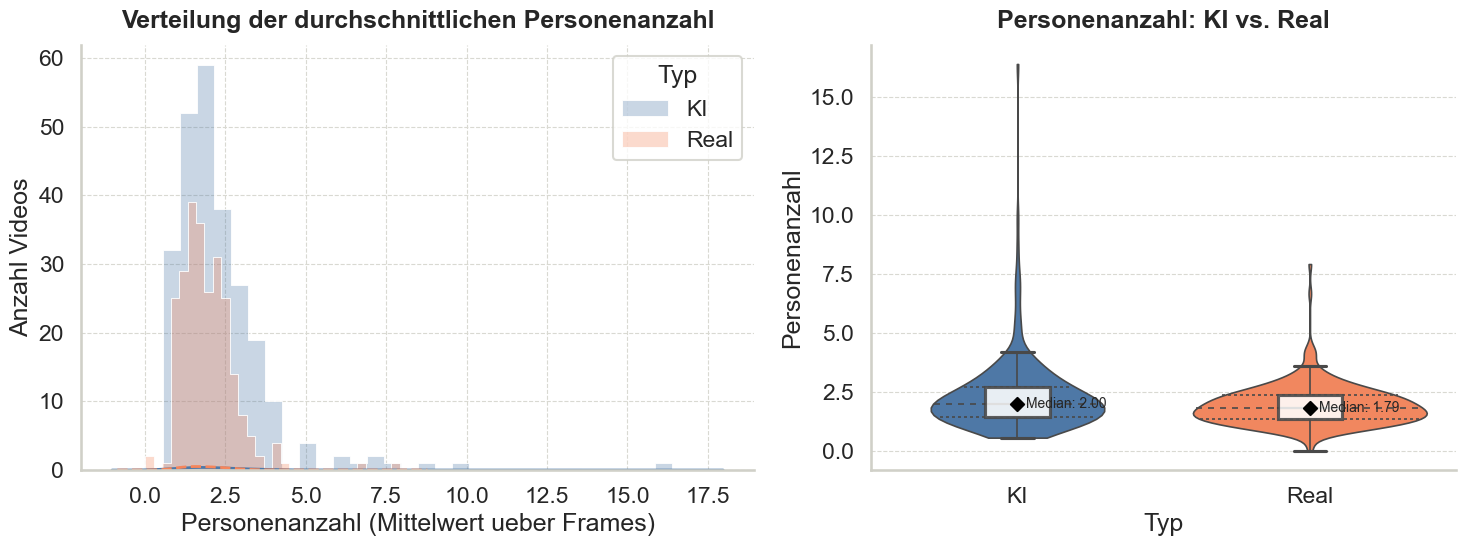

In [6]:
sns.set_theme(style='whitegrid', context='talk', rc={'axes.facecolor': 'white','figure.facecolor': 'white','grid.color': '#d9d9d2','grid.linestyle': '--','grid.linewidth': 0.8,'axes.edgecolor': '#d0d0c8'})
sns.set_palette(['#4C78A8', '#F5855B'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
LINESTYLE = {'KI': '-', 'Real': '--'}
df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={'width_ratios': [1.15, 1]})
for grp in ['KI', 'Real']:
    vals = df_plot.loc[df_plot['typ'] == grp, 'personen_anzahl'].dropna()
    sns.histplot(x=vals, bins=30, stat='count', element='step', fill=True, alpha=0.30, color=PALETTE_COLOR[grp], edgecolor='white', linewidth=0.6, ax=axes[0], label=grp)
    sns.kdeplot(x=vals, color=PALETTE_COLOR[grp], linestyle=LINESTYLE[grp], linewidth=2.0, ax=axes[0], legend=False)
axes[0].set_title('Verteilung der durchschnittlichen Personenanzahl', pad=12, weight='semibold')
axes[0].set_xlabel('Personenanzahl (Mittelwert über Frames)')
axes[0].set_ylabel('Anzahl Videos')
axes[0].legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8')
sns.violinplot(data=df_plot, x='typ', y='personen_anzahl', order=['KI', 'Real'], palette=PALETTE_COLOR, inner='quartile', cut=0, linewidth=1.2, saturation=0.95, ax=axes[1])
sns.boxplot(data=df_plot, x='typ', y='personen_anzahl', order=['KI', 'Real'], width=0.22, fliersize=0, boxprops={'facecolor': 'white', 'alpha': 0.88, 'zorder': 3}, whiskerprops={'linewidth': 1.2}, medianprops={'color': 'black', 'linewidth': 1.6}, ax=axes[1])
med = df_plot.groupby('typ', dropna=False)['personen_anzahl'].median().reindex(['KI', 'Real'])
axes[1].scatter([0, 1], med.values, c='black', s=45, zorder=4, marker='D')
for i, v in enumerate(med.values):
    axes[1].text(i + 0.03, v, f'Median: {v:.2f}', va='center', fontsize=10)
axes[1].set_title('Personenanzahl: KI vs. Real', pad=12, weight='semibold')
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Personenanzahl')
for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()


In [7]:
results = []
metric = 'personen_anzahl'
ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()
if len(ai_vals) > 0 and len(real_vals) > 0:
    u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
    results.append({'metric': metric,'n_ai': len(ai_vals),'n_real': len(real_vals),'mean_ai': ai_vals.mean(),'mean_real': real_vals.mean(),'median_ai': ai_vals.median(),'median_real': real_vals.median(),'u_stat': u_stat,'u_p': u_p})
results_df = pd.DataFrame(results).round(4)
display(results_df)


,metric,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,personen_anzahl,250,250,2.3325,1.9311,2.0,1.7917,35470.5,0.009


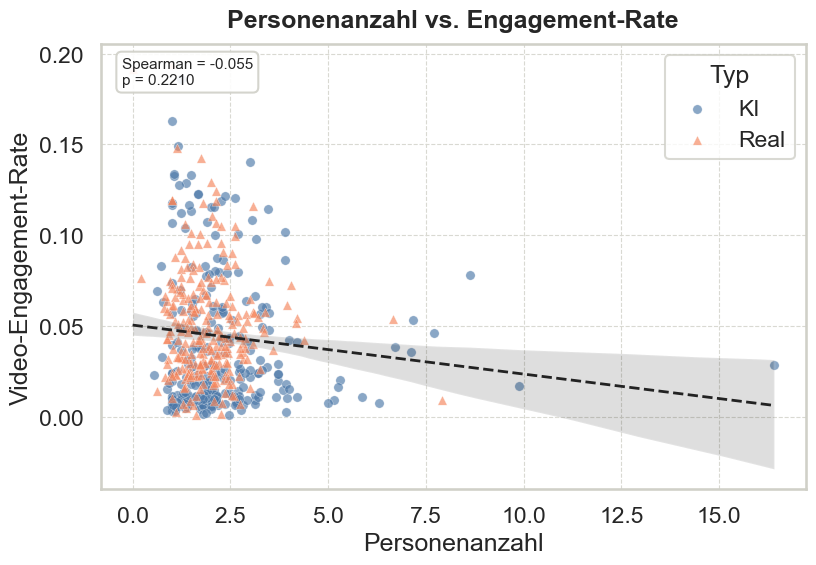

,Metrik,Spearman_rho,p_Wert
0,Personenanzahl,-0.0548,0.221


In [8]:
sns.set_theme(style='whitegrid', context='talk', rc={'axes.facecolor': 'white','figure.facecolor': 'white','grid.color': '#d9d9d2','grid.linestyle': '--','grid.linewidth': 0.8,'axes.edgecolor': '#d0d0c8'})
sns.set_palette(['#4C78A8', '#F5855B'])
df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}
corr_results = []
if 'video_engagement_rate' in df_plot.columns:
    metric_col = 'personen_anzahl'
    metric_label = 'Personenanzahl'
    rho, pval = spearmanr(df_plot[metric_col], df_plot['video_engagement_rate'], nan_policy='omit')
    corr_results.append({'Metrik': metric_label, 'Spearman_rho': rho, 'p_Wert': pval})
    fig, ax = plt.subplots(figsize=(8.5, 6))
    for grp in ['KI', 'Real']:
        sub = df_plot[df_plot['typ'] == grp]
        sns.scatterplot(data=sub, x=metric_col, y='video_engagement_rate', color=PALETTE_COLOR[grp], marker=MARKER[grp], edgecolor='white', linewidth=0.3, s=45, alpha=0.65, ax=ax, label=grp)
    sns.regplot(data=df_plot, x=metric_col, y='video_engagement_rate', scatter=False, ci=95, line_kws={'color': '#222222', 'linewidth': 2.0, 'linestyle': '--'}, ax=ax)
    ax.set_title(f'{metric_label} vs. Engagement-Rate', pad=12, weight='semibold')
    ax.set_xlabel(metric_label)
    ax.set_ylabel('Video-Engagement-Rate')
    ax.text(0.03, 0.97, f'Spearman = {rho:.3f}\np = {pval:.4f}', transform=ax.transAxes, ha='left', va='top', fontsize=11, bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.9))
    ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
    plt.tight_layout()
    plt.show()
else:
    print('video_engagement_rate column not available; skipping correlation analysis.')
corr_df = pd.DataFrame(corr_results).round(4)
display(corr_df)


In [9]:
print('Kurzinterpretation:')
def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'
if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Mittelwertunterschied')
    print(f"- Personenanzahl (personen_anzahl): Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Ein signifikanter Gruppenunterschied weist auf unterschiedlich viele sichtbare Personen hin ({direction}).")
if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']
    p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement-Zusammenhang: Spearman ist {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang zwischen Personenanzahl und Engagement.")


Kurzinterpretation:
- Personenanzahl (personen_anzahl): Mann-Whitney ist signifikant (p=0.0090). Interpretation: Ein signifikanter Gruppenunterschied weist auf unterschiedlich viele sichtbare Personen hin (höher bei KI).
- Engagement-Zusammenhang: Spearman ist nicht signifikant (rho=-0.055, p=0.2210). Interpretation: negativer Zusammenhang zwischen Personenanzahl und Engagement.
